<a href="https://colab.research.google.com/github/sasvi123/Neural_Network/blob/main/E22120_lab04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
# Define CNN model
class CNN(nn.Module):
  def __init__(self):
    super(CNN, self).__init__()
    self.conv1 = nn.Conv2d(
    in_channels=3,
    out_channels=32,
    kernel_size=3
    )
    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
    self.flatten = nn.Flatten()
    self.fc = nn.Linear(32 * 15 * 15, 10)
  def forward(self, x):
    x = self.pool(torch.relu(self.conv1(x)))
    x = self.flatten(x)
    x = self.fc(x)
    return x
# Create an instance of CNN model
model = CNN()

Using device: cpu
--- Training CNN Model (with ReLU & Early Stopping) ---
Epoch [1/20] - Train Loss: 1.6684, Train Acc: 38.60% | Val Loss: 1.3831, Val Acc: 50.05%
Epoch [2/20] - Train Loss: 1.3208, Train Acc: 52.25% | Val Loss: 1.1964, Val Acc: 56.81%
Epoch [3/20] - Train Loss: 1.1836, Train Acc: 57.71% | Val Loss: 1.0535, Val Acc: 62.79%
Epoch [4/20] - Train Loss: 1.0838, Train Acc: 61.52% | Val Loss: 1.0388, Val Acc: 63.43%
Epoch [5/20] - Train Loss: 1.0121, Train Acc: 64.03% | Val Loss: 0.9485, Val Acc: 66.65%
Epoch [6/20] - Train Loss: 0.9486, Train Acc: 66.32% | Val Loss: 0.8599, Val Acc: 69.60%
Epoch [7/20] - Train Loss: 0.9000, Train Acc: 68.06% | Val Loss: 0.8451, Val Acc: 70.50%
Epoch [8/20] - Train Loss: 0.8641, Train Acc: 69.48% | Val Loss: 0.8205, Val Acc: 71.24%
Epoch [9/20] - Train Loss: 0.8330, Train Acc: 70.59% | Val Loss: 0.8070, Val Acc: 71.97%
Epoch [10/20] - Train Loss: 0.8045, Train Acc: 71.49% | Val Loss: 0.7663, Val Acc: 72.89%
Epoch [11/20] - Train Loss: 0.7731,

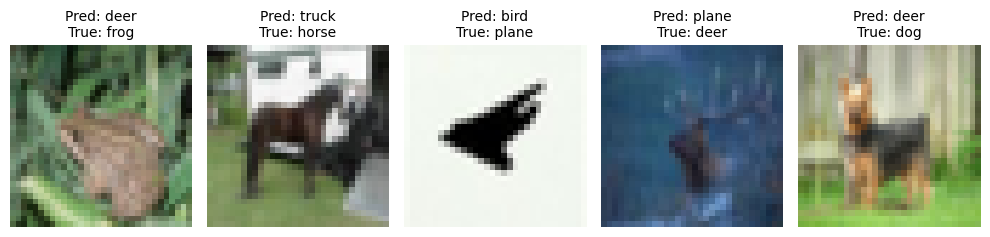


Confusion Matrix:
[[752   7  70  10  18   9  12   6  91  25]
 [  7 849   8   8   4   5   9   4  28  78]
 [ 53   3 680  33  92  46  68  14   7   4]
 [ 13   4  81 478  75 205 101  27   9   7]
 [ 13   1  71  23 760  26  55  43   8   0]
 [  5   1  50 100  56 697  45  33   6   7]
 [  4   1  29  19  35  24 879   1   7   1]
 [ 10   0  34  22  73  63   9 779   6   4]
 [ 26  14  16  14   8   4   7   3 896  12]
 [ 22  56  11  15   7   9   9  11  22 838]]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# -------------------------------------------------------------
# 1. Load, Normalize (0 to 1), and Reshape Data (Tasks 1, 2, 3, 4)
# -------------------------------------------------------------
# CIFAR-10 images are 32x32x3. To normalize between 0 and 1:
# PyTorch ToTensor() automatically scales pixel values from [0, 255] to [0.0, 1.0]
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download full training and test sets
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Split training dataset into Train (80%) and Validation (20%) sets
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# Data Loaders
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# -------------------------------------------------------------
# 5. Implement Advanced CNN Model (Task 5 & 10)
# -------------------------------------------------------------
class AdvancedCNN(nn.Module):
    def __init__(self, activation_fn='relu', dropout_rate=0.3):
        super(AdvancedCNN, self).__init__()

        # Select activation function
        if activation_fn == 'leaky_relu':
            self.act = nn.LeakyReLU(negative_slope=0.01)
        else:
            self.act = nn.ReLU()

        # Layer 1: Input (3, 32, 32) -> Conv -> MaxPool -> Dropout
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (32, 16, 16)
        self.drop1 = nn.Dropout(dropout_rate)

        # Layer 2: Conv -> MaxPool -> Dropout
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (64, 8, 8)
        self.drop2 = nn.Dropout(dropout_rate)

        # Layer 3: Conv -> MaxPool -> Dropout
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Output: (128, 4, 4)
        self.drop3 = nn.Dropout(dropout_rate)

        self.flatten = nn.Flatten()

        # Fully Connected Dense Layers
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.drop_fc = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(512, 10) # 10 Target classes

    def forward(self, x):
        x = self.drop1(self.pool1(self.act(self.conv1(x))))
        x = self.drop2(self.pool2(self.act(self.conv2(x))))
        x = self.drop3(self.pool3(self.act(self.conv3(x))))
        x = self.flatten(x)
        x = self.drop_fc(self.act(self.fc1(x)))
        x = self.fc2(x)
        return x

# -------------------------------------------------------------
# 6 & 11. Training Loop with Early Stopping Implementation
# -------------------------------------------------------------
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train_model(model, criterion, optimizer, epochs=25, use_early_stopping=True):
    early_stopper = EarlyStopping(patience=5)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(epochs):
        # Training Phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100.0 * correct / total

        # Validation Phase
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = 100.0 * val_correct / val_total # Calculate epoch_val_acc here

        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_acc'].append(epoch_train_acc)
        history['val_acc'].append(epoch_val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")

        if use_early_stopping:
            early_stopper(epoch_val_loss)
            if early_stopper.early_stop:
                print("Early stopping triggered. Training stopped.")
                break

    return history

# Instantiate and Compile Model
model = AdvancedCNN(activation_fn='relu').to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
print("--- Training CNN Model (with ReLU & Early Stopping) ---")
history_relu = train_model(model, criterion, optimizer, epochs=20, use_early_stopping=True)

# -------------------------------------------------------------
# 8 & 9. Evaluation and Visualization (Tasks 8, 9)
# -------------------------------------------------------------
model.eval()
all_preds = []
all_labels = []
misclassified_images = []
misclassified_preds = []
misclassified_true = []

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = model(images_dev)
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

        # Track misclassified instances
        misclass_mask = predicted.cpu() != labels
        if misclass_mask.any():
            misclassified_images.extend(images[misclass_mask])
            misclassified_preds.extend(predicted.cpu()[misclass_mask].numpy())
            misclassified_true.extend(labels[misclass_mask].numpy())

# Compute overall test accuracy
test_accuracy = 100.0 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\nFinal Test Accuracy: {test_accuracy:.2f}%")

# Plot Misclassified Images (Task 9)
plt.figure(figsize=(10, 5))
for i in range(min(5, len(misclassified_images))):
    plt.subplot(1, 5, i + 1)
    # PyTorch tensors are (C, H, W), convert to numpy (H, W, C) for plotting
    img = misclassified_images[i].permute(1, 2, 0).numpy()
    plt.imshow(img)
    plt.title(f"Pred: {classes[misclassified_preds[i]]}\nTrue: {classes[misclassified_true[i]]}", fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.show()

# Generate Confusion Matrix for Task 5 analysis
cm = confusion_matrix(all_labels, all_preds)
print("\nConfusion Matrix:")
print(cm)

In [7]:
import re

training_log = """--- Training CNN Model (with ReLU & Early Stopping) ---
Epoch [1/20] - Train Loss: 1.6684, Train Acc: 38.60% | Val Loss: 1.3831, Val Acc: 50.05%
Epoch [2/20] - Train Loss: 1.3208, Train Acc: 52.25% | Val Loss: 1.1964, Val Acc: 56.81%
Epoch [3/20] - Train Loss: 1.1836, Train Acc: 57.71% | Val Loss: 1.0535, Val Acc: 62.79%
Epoch [4/20] - Train Loss: 1.0838, Train Acc: 61.52% | Val Loss: 1.0388, Val Acc: 63.43%
Epoch [5/20] - Train Loss: 1.0121, Train Acc: 64.03% | Val Loss: 0.9485, Val Acc: 66.65%
Epoch [6/20] - Train Loss: 0.9486, Train Acc: 66.32% | Val Loss: 0.8599, Val Acc: 69.60%
Epoch [7/20] - Train Loss: 0.9000, Train Acc: 68.06% | Val Loss: 0.8451, Val Acc: 70.50%
Epoch [8/20] - Train Loss: 0.8641, Train Acc: 69.48% | Val Loss: 0.8205, Val Acc: 71.24%
Epoch [9/20] - Train Loss: 0.8330, Train Acc: 70.59% | Val Loss: 0.8070, Val Acc: 71.97%
Epoch [10/20] - Train Loss: 0.8045, Train Acc: 71.49% | Val Loss: 0.7663, Val Acc: 72.89%
Epoch [11/20] - Train Loss: 0.7731, Train Acc: 72.86% | Val Loss: 0.7996, Val Acc: 72.11%
EarlyStopping counter: 1 out of 5
Epoch [12/20] - Train Loss: 0.7542, Train Acc: 73.18% | Val Loss: 0.7464, Val Acc: 73.82%
Epoch [13/20] - Train Loss: 0.7263, Train Acc: 74.16% | Val Loss: 0.7432, Val Acc: 74.01%
Epoch [14/20] - Train Loss: 0.7051, Train Acc: 74.93% | Val Loss: 0.7461, Val Acc: 74.09%
EarlyStopping counter: 1 out of 5
Epoch [15/20] - Train Loss: 0.6873, Train Acc: 75.50% | Val Loss: 0.7247, Val Acc: 74.98%
Epoch [16/20] - Train Loss: 0.6761, Train Acc: 76.07% | Val Loss: 0.7306, Val Acc: 74.79%
EarlyStopping counter: 1 out of 5
Epoch [17/20] - Train Loss: 0.6598, Train Acc: 76.50% | Val Loss: 0.7211, Val Acc: 75.14%
Epoch [18/20] - Train Loss: 0.6514, Train Acc: 76.74% | Val Loss: 0.7277, Val Acc: 75.22%
EarlyStopping counter: 1 out of 5
Epoch [19/20] - Train Loss: 0.6330, Train Acc: 77.56% | Val Loss: 0.7125, Val Acc: 75.40%
Epoch [20/20] - Train Loss: 0.6246, Train Acc: 77.93% | Val Loss: 0.7123, Val Acc: 75.11%
EarlyStopping counter: 1 out of 5
"""

history_relu = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for line in training_log.split('\n'):
    match = re.search(r"Train Loss: (\d+\.\d+), Train Acc: (\d+\.\d+)% \| Val Loss: (\d+\.\d+), Val Acc: (\d+\.\d+)%", line)
    if match:
        history_relu['train_loss'].append(float(match.group(1)))
        history_relu['train_acc'].append(float(match.group(2)))
        history_relu['val_loss'].append(float(match.group(3)))
        history_relu['val_acc'].append(float(match.group(4)))

print("Parsed history_relu data:")
for key, value in history_relu.items():
    print(f"{key}: {value[:5]}...") # Print first 5 to avoid clutter


Parsed history_relu data:
train_loss: [1.6684, 1.3208, 1.1836, 1.0838, 1.0121]...
val_loss: [1.3831, 1.1964, 1.0535, 1.0388, 0.9485]...
train_acc: [38.6, 52.25, 57.71, 61.52, 64.03]...
val_acc: [50.05, 56.81, 62.79, 63.43, 66.65]...


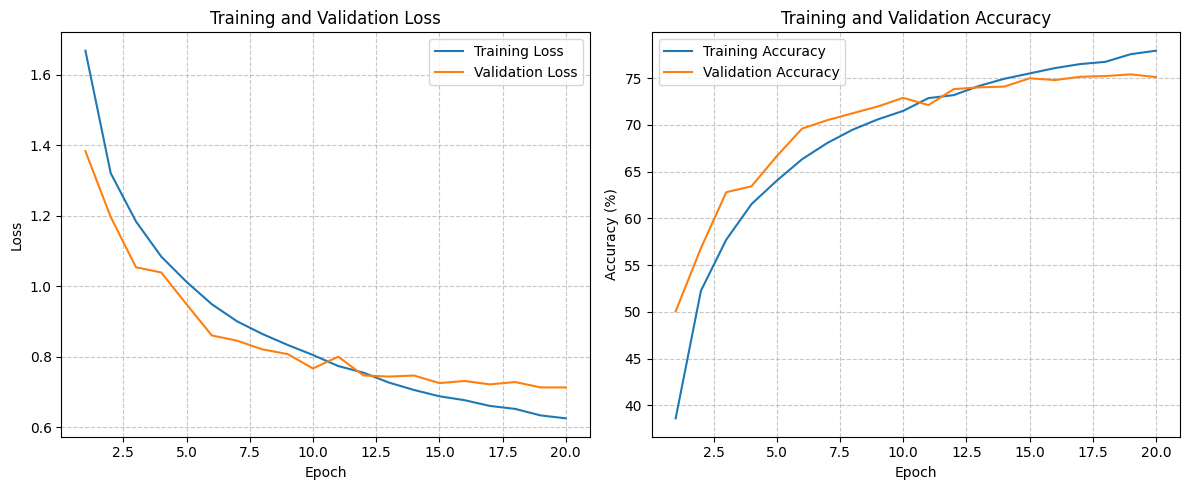

In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_relu['train_loss']) + 1)

plt.figure(figsize=(12, 5))

# Plot Training and Validation Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(epochs, history_relu['train_loss'], label='Training Loss')
plt.plot(epochs, history_relu['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Plot Training and Validation Accuracy
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(epochs, history_relu['train_acc'], label='Training Accuracy')
plt.plot(epochs, history_relu['val_acc'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [6]:
# This cell is redundant as plotting code is included in cell fc02f425. Please execute fc02f425 instead.